# Enviando imagem para o Gemini com UV
Neste notebook, enviamos uma imagem da pasta `imagens` para o modelo `gemini-2.5-flash` usando a SDK `google-genai` do Google.

### 1. Inicializando o Cliente do Gemini
Primeiro, importamos os pacotes necessários e carregamos a chave de acesso da nossa variável de ambiente (`GEMINI_API`) para instanciar o cliente.

In [4]:
import os
from dotenv import load_dotenv
from google import genai
from PIL import Image

# Carrega variáveis de ambiente (GEMINI_API)
load_dotenv()
api_key = os.getenv('GEMINI_API') or os.getenv('GEMINI_API_KEY')
if api_key:
    api_key = api_key.strip()

# Inicializa o cliente Gemini
client = genai.Client(api_key=api_key)


### 2. Carregando a Imagem Alvo
Nesta etapa, utilizamos o Pillow (`PIL`) para processar e exibir a imagem alvo armazenada localmente na nossa pasta `imagens/`.

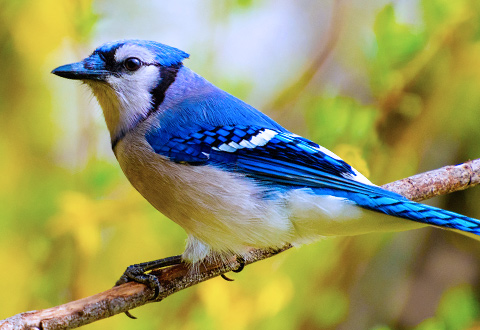

In [5]:
# Carregar a imagem. Vamos usar a 'bird.png.jpg' da pasta imagens
image_path = 'imagens/bird.png.jpg'
img = Image.open(image_path)
img


### 3. Extraindo Saídas Estruturadas com Pydantic
Por fim, definimos uma classe `ImageAnalysis` usando o **Pydantic** para forçar que o Gemini retorne o JSON estritamente dentro da estrutura e tipos previstos. Passamos esse esquema na configuração base `generate_content`.

In [6]:
from pydantic import BaseModel, Field
from google.genai import types

class ImageAnalysis(BaseModel):
    objects: list[str] = Field(description="Lista de objetos predominantes na imagem")
    colors: list[str] = Field(description="Cores principais encontradas na imagem")
    description: str = Field(description="Uma breve descrição da cena")

# Chama a API para descrever a imagem com saída estruturada
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        'Analise a imagem e extraia os elementos de acordo com a estrutura solicitada.',
        img
    ],
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=ImageAnalysis,
    )
)
print(response.text)


{"objects": ["pássaro", "gaio-azul", "galho", "folhagem"], "colors": ["azul", "branco", "preto", "cinza", "marrom", "amarelo", "verde"], "description": "Uma imagem detalhada de um gaio-azul vibrante empoleirado em um galho, com um fundo desfocado de folhagem amarela e verde."}
